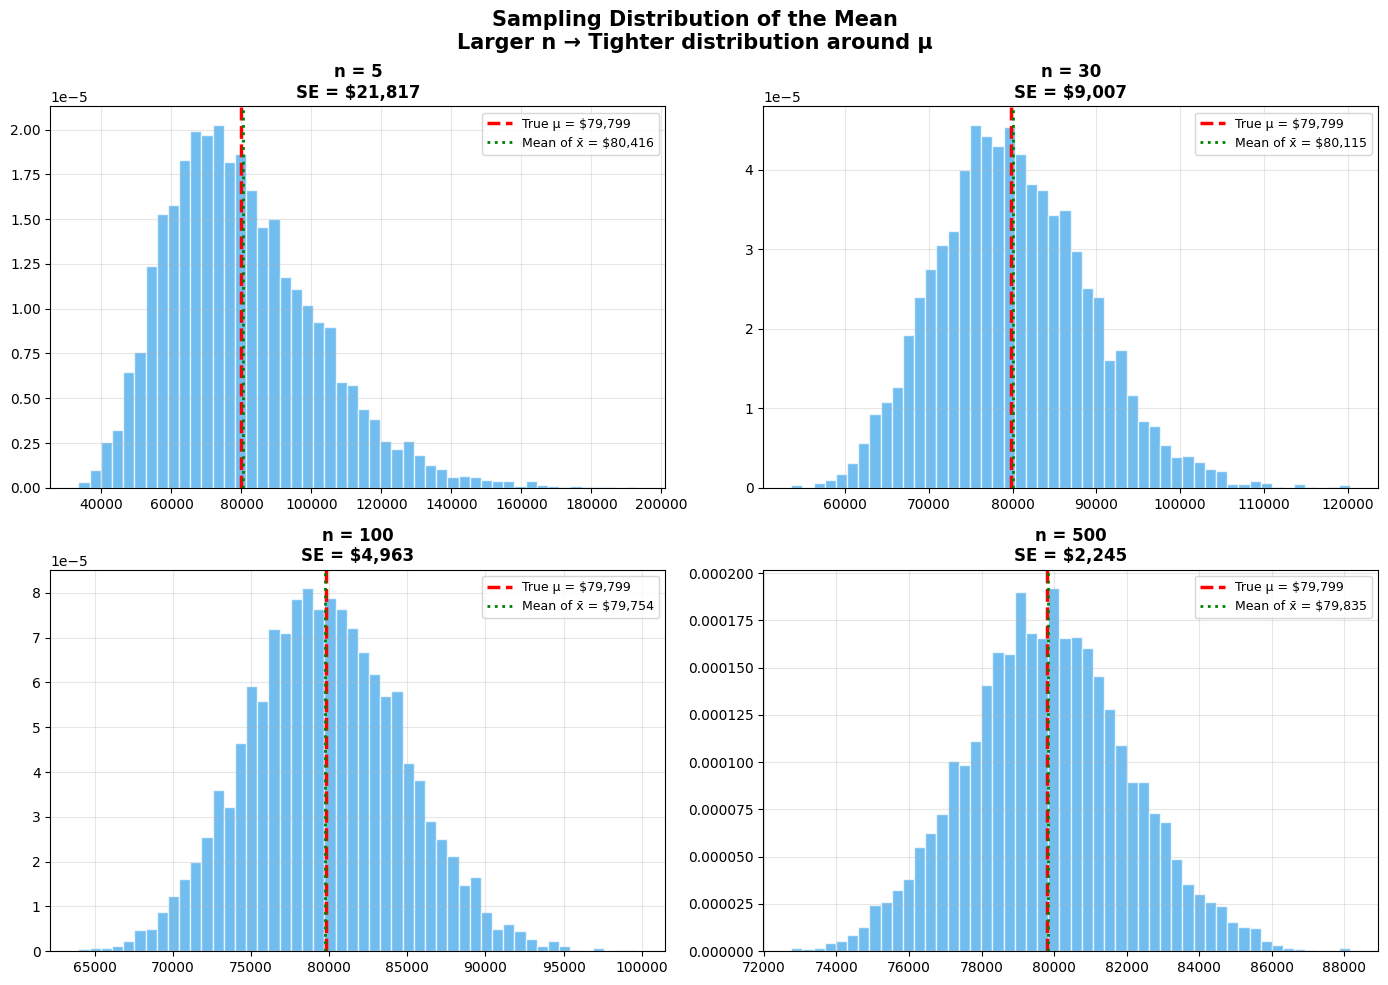

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# True population: Salary data (right-skewed)
population = np.random.exponential(50000, 100_000) + 30000
true_mean = population.mean()

# Take many samples and compute sample means
sample_sizes = [5, 30, 100, 500]
n_samples = 5000

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, n in zip(axes.flat, sample_sizes):
    sample_means = [np.random.choice(population, n).mean() for _ in range(n_samples)]
    
    ax.hist(sample_means, bins=50, density=True, alpha=0.7, color='#36A2EB', edgecolor='white')
    ax.axvline(true_mean, color='red', linestyle='--', linewidth=2.5, label=f'True μ = ${true_mean:,.0f}')
    ax.axvline(np.mean(sample_means), color='green', linestyle=':', linewidth=2, label=f'Mean of x̄ = ${np.mean(sample_means):,.0f}')
    
    se = np.std(sample_means)
    ax.set_title(f'n = {n}\nSE = ${se:,.0f}', fontweight='bold', fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Sampling Distribution of the Mean\nLarger n → Tighter distribution around μ', 
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('sampling_distribution.png', dpi=150)
plt.show()

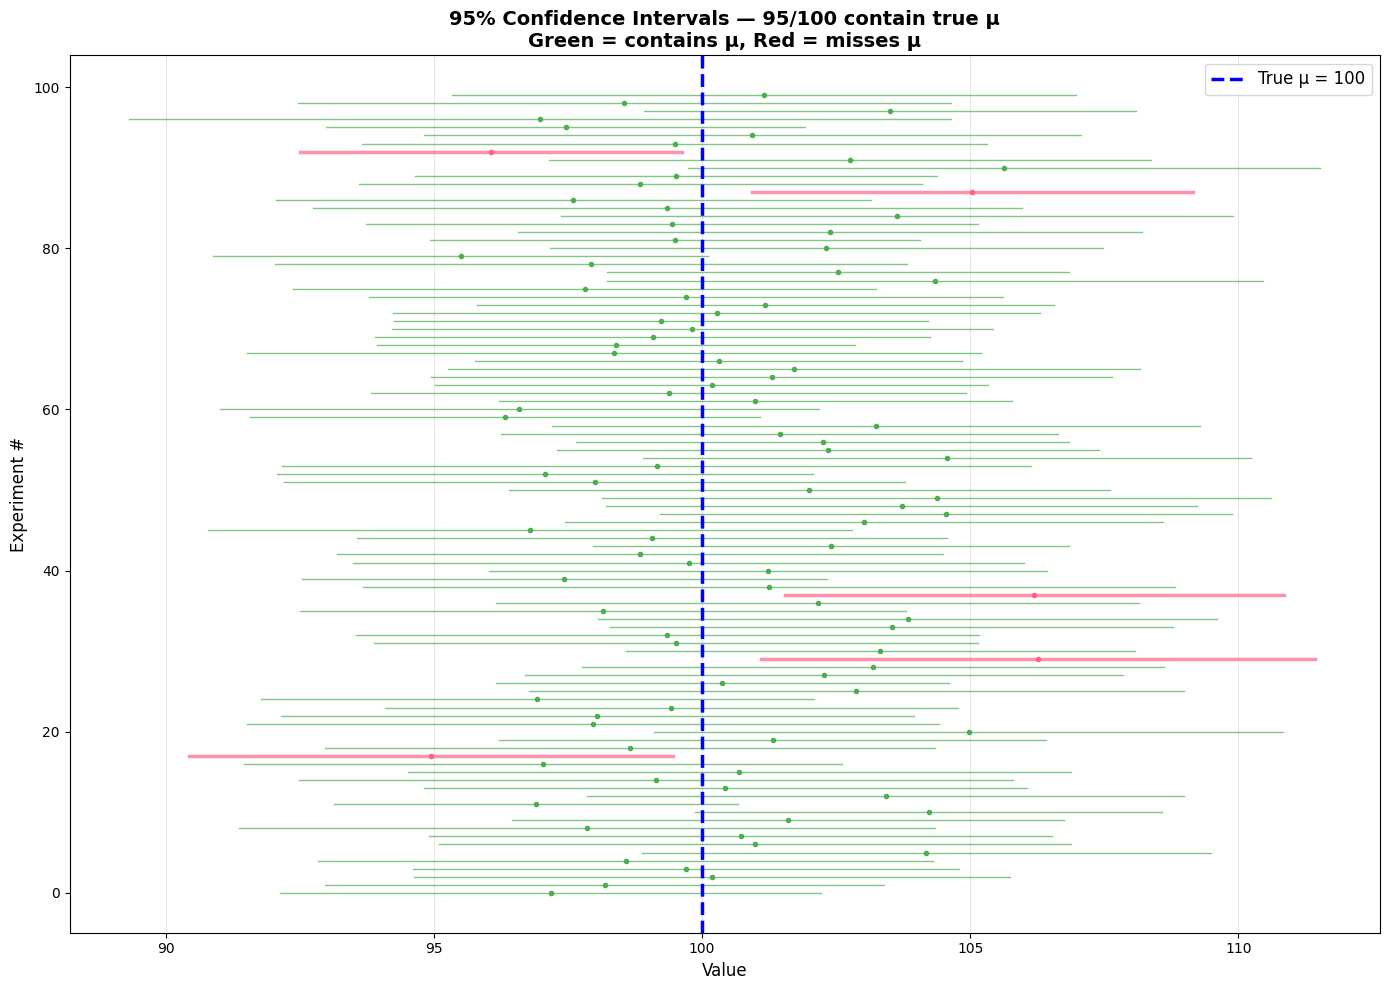

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)

# Demonstrate that 95% of CIs contain the true mean
true_mean = 100
true_std = 15
n = 30
n_experiments = 100
alpha = 0.05

fig, ax = plt.subplots(figsize=(14, 10))

contains_true = 0
for i in range(n_experiments):
    sample = np.random.normal(true_mean, true_std, n)
    x_bar = sample.mean()
    se = sample.std(ddof=1) / np.sqrt(n)
    t_crit = stats.t.ppf(1 - alpha / 2, df=n - 1)
    ci_low = x_bar - t_crit * se
    ci_high = x_bar + t_crit * se
    
    contains = ci_low <= true_mean <= ci_high
    contains_true += contains
    color = '#4CAF50' if contains else '#FF6384'
    linewidth = 1 if contains else 2.5
    
    ax.plot([ci_low, ci_high], [i, i], color=color, linewidth=linewidth, alpha=0.7)
    ax.plot(x_bar, i, 'o', color=color, markersize=3)

ax.axvline(true_mean, color='blue', linestyle='--', linewidth=2.5, label=f'True μ = {true_mean}')
ax.set_xlabel('Value', fontsize=12)
ax.set_ylabel('Experiment #', fontsize=12)
ax.set_title(f'95% Confidence Intervals — {contains_true}/{n_experiments} contain true μ\n'
             f'Green = contains μ, Red = misses μ', fontweight='bold', fontsize=14)
ax.legend(fontsize=12, loc='upper right')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('confidence_intervals.png', dpi=150)
plt.show()

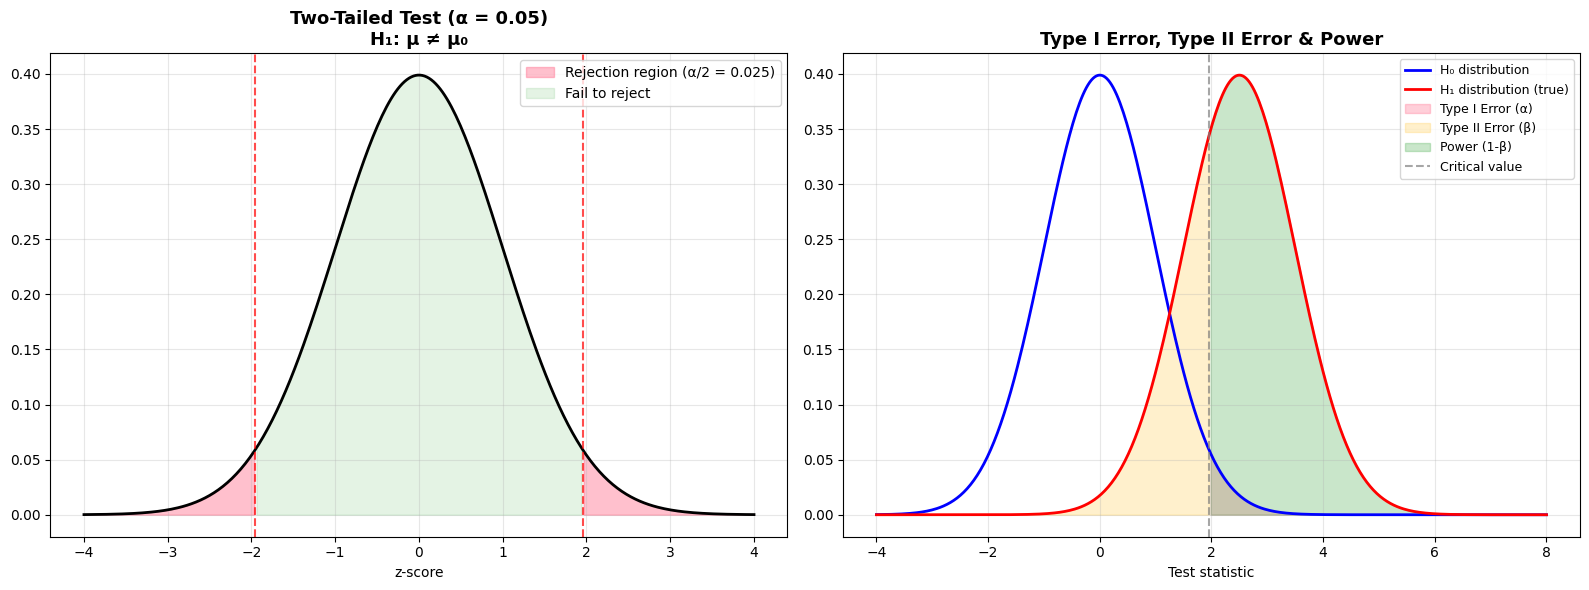

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

x = np.linspace(-4, 4, 300)
pdf = stats.norm.pdf(x)

# Two-tailed test
ax = axes[0]
ax.plot(x, pdf, 'k-', linewidth=2)
ax.fill_between(x, pdf, where=(x <= -1.96), alpha=0.4, color='#FF6384', label='Rejection region (α/2 = 0.025)')
ax.fill_between(x, pdf, where=(x >= 1.96), alpha=0.4, color='#FF6384')
ax.fill_between(x, pdf, where=(x > -1.96) & (x < 1.96), alpha=0.15, color='#4CAF50', label='Fail to reject')
ax.axvline(-1.96, color='red', linestyle='--', alpha=0.7)
ax.axvline(1.96, color='red', linestyle='--', alpha=0.7)
ax.set_title('Two-Tailed Test (α = 0.05)\nH₁: μ ≠ μ₀', fontweight='bold', fontsize=13)
ax.legend(fontsize=10)
ax.set_xlabel('z-score')
ax.grid(True, alpha=0.3)

# Type I and Type II errors
ax = axes[1]
x2 = np.linspace(-4, 8, 400)
pdf_h0 = stats.norm.pdf(x2, loc=0, scale=1)
pdf_h1 = stats.norm.pdf(x2, loc=2.5, scale=1)

ax.plot(x2, pdf_h0, 'b-', linewidth=2, label='H₀ distribution')
ax.plot(x2, pdf_h1, 'r-', linewidth=2, label='H₁ distribution (true)')
ax.fill_between(x2, pdf_h0, where=(x2 >= 1.96), alpha=0.3, color='#FF6384', label='Type I Error (α)')
ax.fill_between(x2, pdf_h1, where=(x2 <= 1.96), alpha=0.3, color='#FFCE56', label='Type II Error (β)')
ax.fill_between(x2, pdf_h1, where=(x2 > 1.96), alpha=0.3, color='#4CAF50', label='Power (1-β)')
ax.axvline(1.96, color='gray', linestyle='--', alpha=0.7, label='Critical value')
ax.set_title('Type I Error, Type II Error & Power', fontweight='bold', fontsize=13)
ax.legend(fontsize=9, loc='upper right')
ax.set_xlabel('Test statistic')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('hypothesis_testing.png', dpi=150)
plt.show()

In [3]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

np.random.seed(42)

# =============================================
# 1. Independent Two-Sample t-test
# =============================================
print("=" * 60)
print("1. INDEPENDENT TWO-SAMPLE T-TEST")
print("=" * 60)
print("Question: Do two teaching methods produce different exam scores?\n")

method_A = np.random.normal(75, 10, 40)  # Mean 75, std 10
method_B = np.random.normal(80, 12, 40)  # Mean 80, std 12

t_stat, p_value = stats.ttest_ind(method_A, method_B, equal_var=False)  # Welch's t-test
cohens_d = (method_B.mean() - method_A.mean()) / np.sqrt((method_A.std()**2 + method_B.std()**2) / 2)

print(f"Method A: mean = {method_A.mean():.2f}, std = {method_A.std():.2f}")
print(f"Method B: mean = {method_B.mean():.2f}, std = {method_B.std():.2f}")
print(f"t-statistic = {t_stat:.4f}")
print(f"p-value = {p_value:.6f}")
print(f"Cohen's d = {cohens_d:.4f}")
print(f"Result: {'Significant difference!' if p_value < 0.05 else 'No significant difference'}")

# =============================================
# 2. Paired t-test
# =============================================
print("\n" + "=" * 60)
print("2. PAIRED T-TEST")
print("=" * 60)
print("Question: Does a training program improve employee performance?\n")

before = np.random.normal(70, 8, 30)
improvement = np.random.normal(5, 3, 30)  # Average improvement of 5 points
after = before + improvement

t_stat, p_value = stats.ttest_rel(after, before)
print(f"Before: mean = {before.mean():.2f}")
print(f"After:  mean = {after.mean():.2f}")
print(f"Mean difference = {(after - before).mean():.2f}")
print(f"t-statistic = {t_stat:.4f}")
print(f"p-value = {p_value:.6f}")
print(f"Result: {'Significant improvement!' if p_value < 0.05 else 'No significant change'}")

# =============================================
# 3. ANOVA
# =============================================
print("\n" + "=" * 60)
print("3. ONE-WAY ANOVA")
print("=" * 60)
print("Question: Do 4 fertilizers produce different crop yields?\n")

fert_A = np.random.normal(50, 5, 30)
fert_B = np.random.normal(55, 6, 30)
fert_C = np.random.normal(52, 5, 30)
fert_D = np.random.normal(58, 7, 30)

f_stat, p_value = stats.f_oneway(fert_A, fert_B, fert_C, fert_D)
print(f"F-statistic = {f_stat:.4f}")
print(f"p-value = {p_value:.6f}")
print(f"Result: {'At least one group differs!' if p_value < 0.05 else 'No significant difference'}")

# =============================================
# 4. Chi-Squared Test
# =============================================
print("\n" + "=" * 60)
print("4. CHI-SQUARED TEST OF INDEPENDENCE")
print("=" * 60)
print("Question: Is purchase behavior related to age group?\n")

# Contingency table: Age groups × Product choices
observed = np.array([
    [50, 30, 20],   # Young: [Product A, B, C]
    [35, 40, 25],   # Middle: [Product A, B, C]
    [15, 30, 55]    # Older: [Product A, B, C]
])

chi2, p_value, dof, expected = stats.chi2_contingency(observed)
print(f"Observed:\n{observed}")
print(f"\nExpected (if independent):\n{expected.round(1)}")
print(f"\nChi-squared = {chi2:.4f}")
print(f"p-value = {p_value:.6f}")
print(f"Degrees of freedom = {dof}")
print(f"Result: {'Variables are associated!' if p_value < 0.05 else 'No association'}")

1. INDEPENDENT TWO-SAMPLE T-TEST
Question: Do two teaching methods produce different exam scores?

Method A: mean = 72.81, std = 9.41
Method B: mean = 79.65, std = 11.43
t-statistic = -2.8843
p-value = 0.005115
Cohen's d = 0.6532
Result: Significant difference!

2. PAIRED T-TEST
Question: Does a training program improve employee performance?

Before: mean = 69.74
After:  mean = 74.65
Mean difference = 4.91
t-statistic = 8.1518
p-value = 0.000000
Result: Significant improvement!

3. ONE-WAY ANOVA
Question: Do 4 fertilizers produce different crop yields?

F-statistic = 9.5867
p-value = 0.000010
Result: At least one group differs!

4. CHI-SQUARED TEST OF INDEPENDENCE
Question: Is purchase behavior related to age group?

Observed:
[[50 30 20]
 [35 40 25]
 [15 30 55]]

Expected (if independent):
[[33.3 33.3 33.3]
 [33.3 33.3 33.3]
 [33.3 33.3 33.3]]

Chi-squared = 42.0000
p-value = 0.000000
Degrees of freedom = 4
Result: Variables are associated!


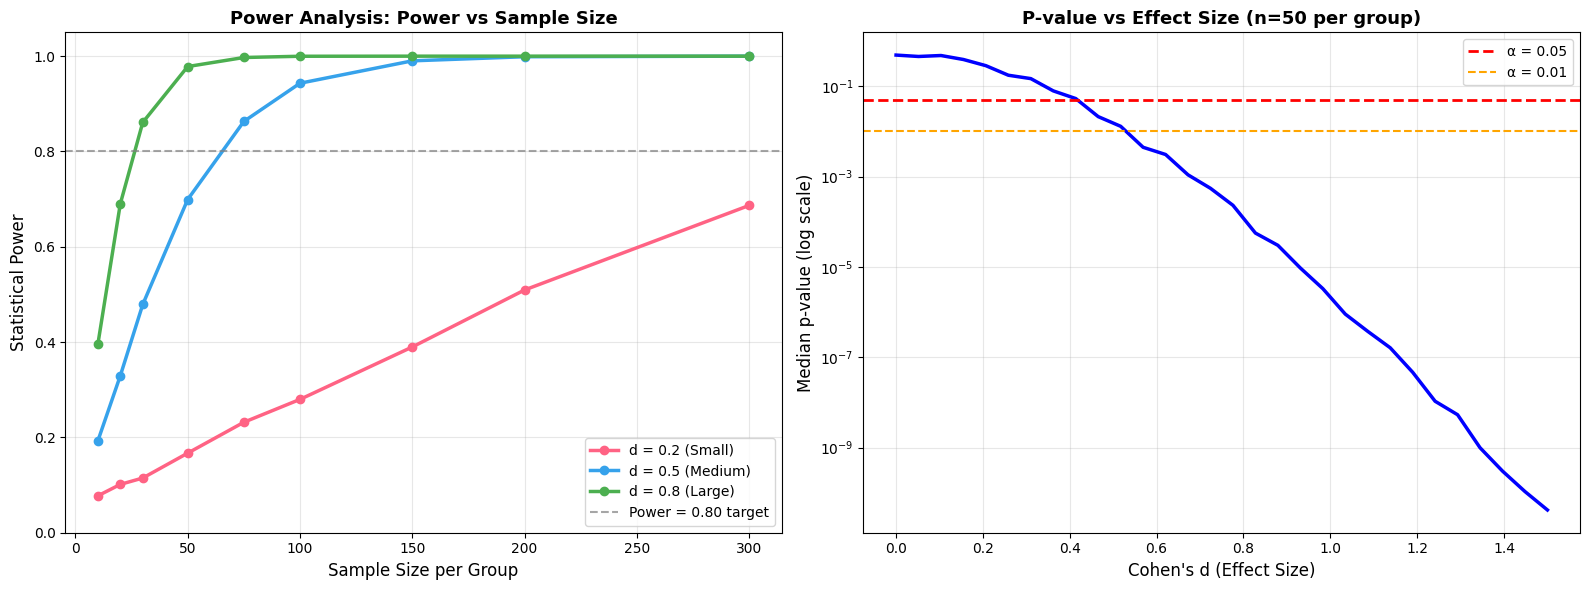

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Power analysis: how sample size affects power
def compute_power(n, effect_size, alpha=0.05, n_simulations=5000):
    """Simulate power for a two-sample t-test."""
    rejections = 0
    for _ in range(n_simulations):
        group_a = np.random.normal(0, 1, n)
        group_b = np.random.normal(effect_size, 1, n)
        _, p = stats.ttest_ind(group_a, group_b)
        if p < alpha:
            rejections += 1
    return rejections / n_simulations

np.random.seed(42)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Power vs Sample Size for different effect sizes
sample_sizes = [10, 20, 30, 50, 75, 100, 150, 200, 300]
effect_sizes = [0.2, 0.5, 0.8]
colors = ['#FF6384', '#36A2EB', '#4CAF50']

for d, color in zip(effect_sizes, colors):
    powers = [compute_power(n, d) for n in sample_sizes]
    axes[0].plot(sample_sizes, powers, 'o-', color=color, linewidth=2.5, markersize=6, 
                 label=f'd = {d} ({["Small", "Medium", "Large"][effect_sizes.index(d)]})')

axes[0].axhline(y=0.8, color='gray', linestyle='--', linewidth=1.5, alpha=0.7, label='Power = 0.80 target')
axes[0].set_xlabel('Sample Size per Group', fontsize=12)
axes[0].set_ylabel('Statistical Power', fontsize=12)
axes[0].set_title('Power Analysis: Power vs Sample Size', fontweight='bold', fontsize=13)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([0, 1.05])

# Plot 2: P-value vs Effect Size (fixed n)
n_fixed = 50
effect_range = np.linspace(0, 1.5, 30)
p_values_sim = []
for d in effect_range:
    p_vals = []
    for _ in range(500):
        g1 = np.random.normal(0, 1, n_fixed)
        g2 = np.random.normal(d, 1, n_fixed)
        _, p = stats.ttest_ind(g1, g2)
        p_vals.append(p)
    p_values_sim.append(np.median(p_vals))

axes[1].semilogy(effect_range, p_values_sim, 'b-', linewidth=2.5)
axes[1].axhline(y=0.05, color='red', linestyle='--', linewidth=2, label='α = 0.05')
axes[1].axhline(y=0.01, color='orange', linestyle='--', linewidth=1.5, label='α = 0.01')
axes[1].set_xlabel("Cohen's d (Effect Size)", fontsize=12)
axes[1].set_ylabel('Median p-value (log scale)', fontsize=12)
axes[1].set_title(f'P-value vs Effect Size (n={n_fixed} per group)', fontweight='bold', fontsize=13)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('power_analysis.png', dpi=150)
plt.show()

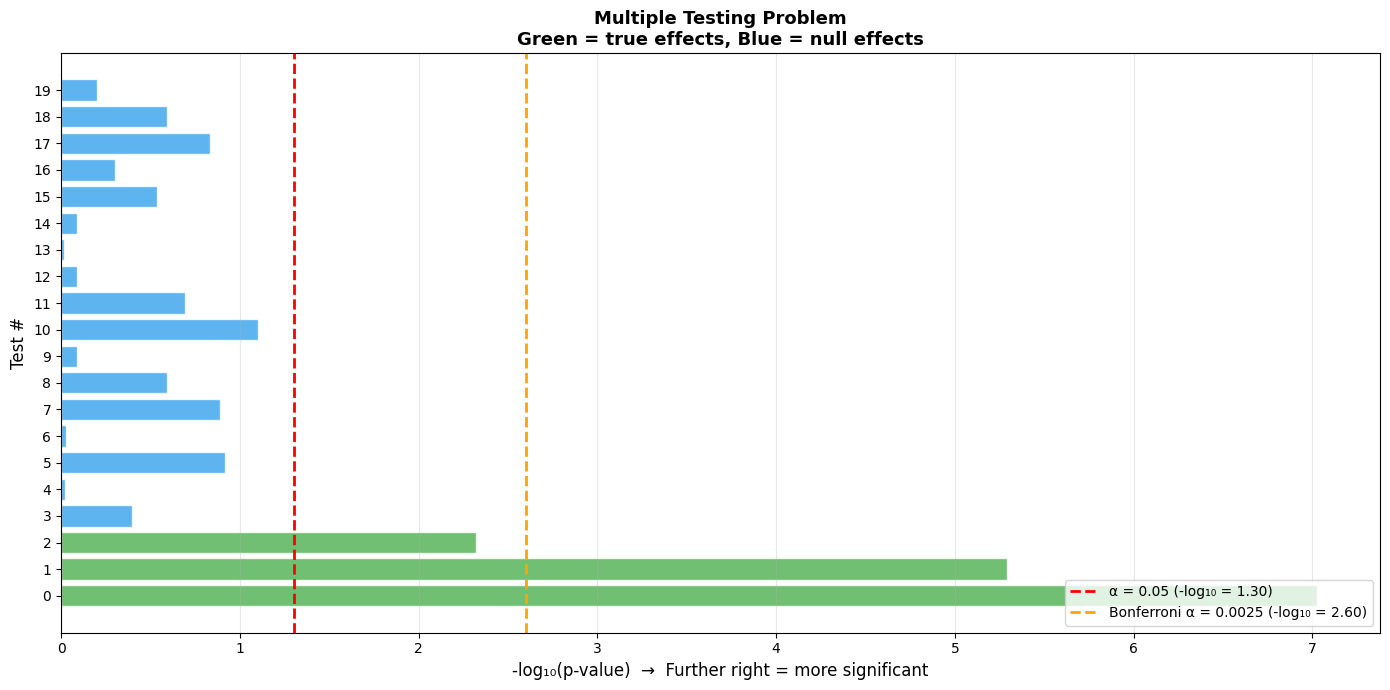

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)

# Simulate: 20 hypothesis tests, only 3 have real effects
n_tests = 20
n_true_effects = 3
n_samples = 50

p_values = []
is_true_effect = []

for i in range(n_tests):
    group1 = np.random.normal(0, 1, n_samples)
    if i < n_true_effects:
        # Real effect (d = 0.8)
        group2 = np.random.normal(0.8, 1, n_samples)
        is_true_effect.append(True)
    else:
        # No effect (null is true)
        group2 = np.random.normal(0, 1, n_samples)
        is_true_effect.append(False)
    
    _, p = stats.ttest_ind(group1, group2)
    p_values.append(p)

p_values = np.array(p_values)
is_true_effect = np.array(is_true_effect)

# Apply corrections
alpha = 0.05
bonferroni_alpha = alpha / n_tests

# Benjamini-Hochberg
sorted_indices = np.argsort(p_values)
sorted_p = p_values[sorted_indices]
bh_thresholds = np.arange(1, n_tests + 1) / n_tests * alpha
bh_reject = np.zeros(n_tests, dtype=bool)
max_k = 0
for k in range(n_tests):
    if sorted_p[k] <= bh_thresholds[k]:
        max_k = k + 1
bh_reject[sorted_indices[:max_k]] = True

fig, ax = plt.subplots(figsize=(14, 7))

colors = ['#4CAF50' if te else '#36A2EB' for te in is_true_effect]
bars = ax.barh(range(n_tests), -np.log10(p_values), color=colors, edgecolor='white', alpha=0.8)

# Thresholds
ax.axvline(-np.log10(0.05), color='red', linestyle='--', linewidth=2, label=f'α = 0.05 (-log₁₀ = {-np.log10(0.05):.2f})')
ax.axvline(-np.log10(bonferroni_alpha), color='orange', linestyle='--', linewidth=2, 
           label=f'Bonferroni α = {bonferroni_alpha:.4f} (-log₁₀ = {-np.log10(bonferroni_alpha):.2f})')

ax.set_xlabel('-log₁₀(p-value)  →  Further right = more significant', fontsize=12)
ax.set_ylabel('Test #', fontsize=12)
ax.set_title(f'Multiple Testing Problem\n'
             f'Green = true effects, Blue = null effects', fontweight='bold', fontsize=13)
ax.legend(fontsize=10, loc='lower right')
ax.set_yticks(range(n_tests))
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('multiple_testing.png', dpi=150)
plt.show()

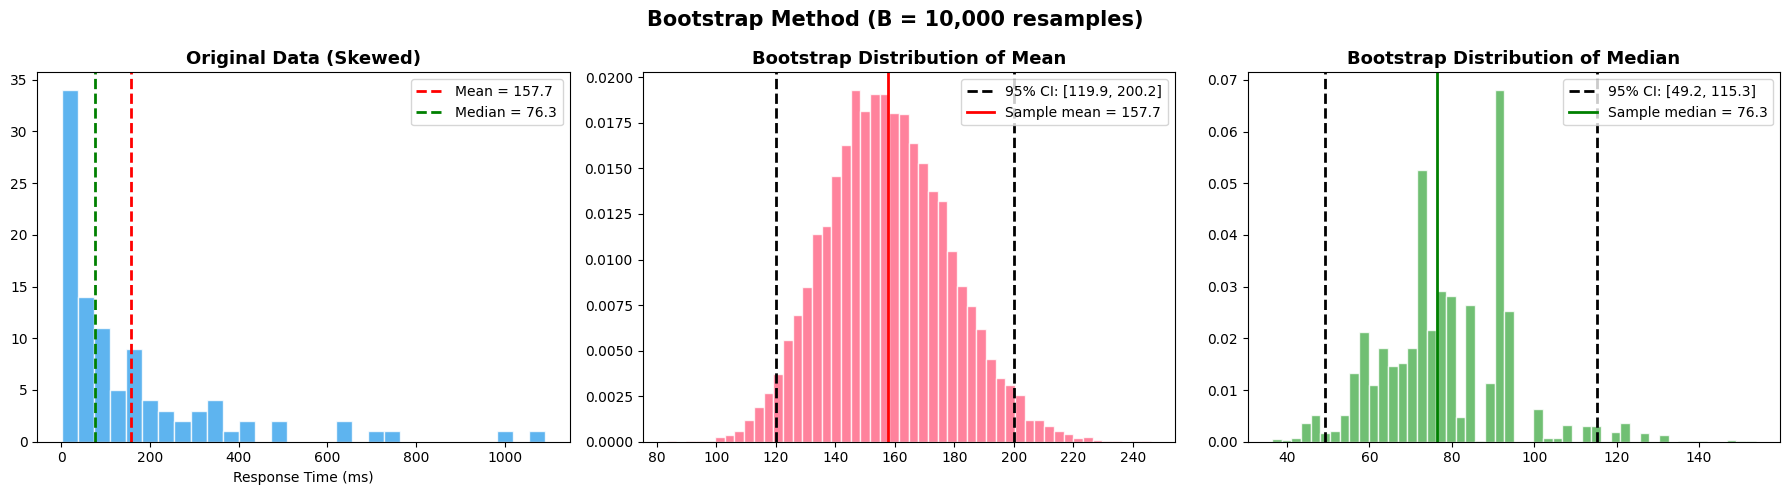

In [6]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Real-world data: response times (ms) — clearly skewed
data = np.concatenate([
    np.random.exponential(100, 80),
    np.random.exponential(500, 20)  # Some slow outliers
])

n = len(data)
B = 10000  # Number of bootstrap samples

# Bootstrap for the mean
bootstrap_means = []
bootstrap_medians = []
for _ in range(B):
    resample = np.random.choice(data, size=n, replace=True)
    bootstrap_means.append(np.mean(resample))
    bootstrap_medians.append(np.median(resample))

bootstrap_means = np.array(bootstrap_means)
bootstrap_medians = np.array(bootstrap_medians)

# Bootstrap 95% CI
ci_mean = np.percentile(bootstrap_means, [2.5, 97.5])
ci_median = np.percentile(bootstrap_medians, [2.5, 97.5])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Original data
axes[0].hist(data, bins=30, color='#36A2EB', edgecolor='white', alpha=0.8)
axes[0].axvline(np.mean(data), color='red', linestyle='--', lw=2, label=f'Mean = {np.mean(data):.1f}')
axes[0].axvline(np.median(data), color='green', linestyle='--', lw=2, label=f'Median = {np.median(data):.1f}')
axes[0].set_title('Original Data (Skewed)', fontweight='bold', fontsize=13)
axes[0].legend(fontsize=10)
axes[0].set_xlabel('Response Time (ms)')

# Bootstrap distribution of the mean
axes[1].hist(bootstrap_means, bins=50, color='#FF6384', edgecolor='white', alpha=0.8, density=True)
axes[1].axvline(ci_mean[0], color='black', linestyle='--', lw=2, label=f'95% CI: [{ci_mean[0]:.1f}, {ci_mean[1]:.1f}]')
axes[1].axvline(ci_mean[1], color='black', linestyle='--', lw=2)
axes[1].axvline(np.mean(data), color='red', linestyle='-', lw=2, label=f'Sample mean = {np.mean(data):.1f}')
axes[1].set_title('Bootstrap Distribution of Mean', fontweight='bold', fontsize=13)
axes[1].legend(fontsize=10)

# Bootstrap distribution of the median
axes[2].hist(bootstrap_medians, bins=50, color='#4CAF50', edgecolor='white', alpha=0.8, density=True)
axes[2].axvline(ci_median[0], color='black', linestyle='--', lw=2, label=f'95% CI: [{ci_median[0]:.1f}, {ci_median[1]:.1f}]')
axes[2].axvline(ci_median[1], color='black', linestyle='--', lw=2)
axes[2].axvline(np.median(data), color='green', linestyle='-', lw=2, label=f'Sample median = {np.median(data):.1f}')
axes[2].set_title('Bootstrap Distribution of Median', fontweight='bold', fontsize=13)
axes[2].legend(fontsize=10)

plt.suptitle(f'Bootstrap Method (B = {B:,} resamples)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('bootstrap.png', dpi=150)
plt.show()

In [7]:
import numpy as np
from scipy import stats

class HypothesisTest:
    """From-scratch hypothesis testing framework."""
    
    @staticmethod
    def one_sample_t_test(data, mu_0, alpha=0.05, alternative='two-sided'):
        """
        Test if the population mean equals mu_0.
        
        H0: mu = mu_0
        H1: mu != mu_0 (two-sided) or mu > mu_0 or mu < mu_0
        """
        n = len(data)
        x_bar = np.mean(data)
        s = np.std(data, ddof=1)
        se = s / np.sqrt(n)
        
        # Test statistic
        t_stat = (x_bar - mu_0) / se
        
        # P-value
        if alternative == 'two-sided':
            p_value = 2 * (1 - stats.t.cdf(abs(t_stat), df=n-1))
        elif alternative == 'greater':
            p_value = 1 - stats.t.cdf(t_stat, df=n-1)
        elif alternative == 'less':
            p_value = stats.t.cdf(t_stat, df=n-1)
        
        # Confidence interval
        t_crit = stats.t.ppf(1 - alpha/2, df=n-1)
        ci = (x_bar - t_crit * se, x_bar + t_crit * se)
        
        # Effect size (Cohen's d)
        cohens_d = (x_bar - mu_0) / s
        
        return {
            'test': 'One-Sample t-test',
            't_statistic': t_stat,
            'p_value': p_value,
            'reject_H0': p_value < alpha,
            'confidence_interval': ci,
            'effect_size_d': cohens_d,
            'sample_mean': x_bar,
            'sample_std': s,
            'n': n
        }
    
    @staticmethod
    def two_sample_t_test(data1, data2, alpha=0.05, equal_var=False):
        """
        Welch's t-test for comparing two independent group means.
        
        H0: mu1 = mu2
        H1: mu1 != mu2
        """
        n1, n2 = len(data1), len(data2)
        x1, x2 = np.mean(data1), np.mean(data2)
        s1, s2 = np.std(data1, ddof=1), np.std(data2, ddof=1)
        
        # Welch's t-test (no equal variance assumption)
        se = np.sqrt(s1**2/n1 + s2**2/n2)
        t_stat = (x1 - x2) / se
        
        # Welch-Satterthwaite degrees of freedom
        df = (s1**2/n1 + s2**2/n2)**2 / ((s1**2/n1)**2/(n1-1) + (s2**2/n2)**2/(n2-1))
        
        p_value = 2 * (1 - stats.t.cdf(abs(t_stat), df=df))
        
        # Cohen's d
        s_pooled = np.sqrt((s1**2 + s2**2) / 2)
        cohens_d = (x1 - x2) / s_pooled
        
        return {
            'test': "Welch's Two-Sample t-test",
            't_statistic': t_stat,
            'p_value': p_value,
            'reject_H0': p_value < alpha,
            'degrees_of_freedom': df,
            'effect_size_d': cohens_d,
            'mean_diff': x1 - x2,
            'group1_mean': x1,
            'group2_mean': x2
        }
    
    @staticmethod
    def bootstrap_test(data1, data2, n_bootstrap=10000, alpha=0.05):
        """
        Non-parametric bootstrap hypothesis test.
        Tests if two groups have the same mean.
        """
        observed_diff = np.mean(data1) - np.mean(data2)
        
        # Under H0: combine all data, then randomly split
        combined = np.concatenate([data1, data2])
        n1 = len(data1)
        
        bootstrap_diffs = []
        for _ in range(n_bootstrap):
            perm = np.random.permutation(combined)
            boot_diff = np.mean(perm[:n1]) - np.mean(perm[n1:])
            bootstrap_diffs.append(boot_diff)
        
        bootstrap_diffs = np.array(bootstrap_diffs)
        
        # Two-tailed p-value
        p_value = np.mean(np.abs(bootstrap_diffs) >= np.abs(observed_diff))
        
        return {
            'test': 'Bootstrap Permutation Test',
            'observed_diff': observed_diff,
            'p_value': p_value,
            'reject_H0': p_value < alpha,
        }


# ============ DEMONSTRATION ============
np.random.seed(42)

# Scenario: Do experienced employees get higher performance reviews?
junior = np.random.normal(72, 12, 45)
senior = np.random.normal(78, 10, 40)

ht = HypothesisTest()

# Parametric test
result = ht.two_sample_t_test(senior, junior)
print("=" * 60)
print(f"Test: {result['test']}")
print(f"Mean difference: {result['mean_diff']:.2f}")
print(f"t-statistic: {result['t_statistic']:.4f}")
print(f"p-value: {result['p_value']:.6f}")
print(f"Cohen's d: {result['effect_size_d']:.4f}")
print(f"Reject H₀? {result['reject_H0']}")

# Non-parametric bootstrap test
boot_result = ht.bootstrap_test(senior, junior)
print(f"\n{boot_result['test']}")
print(f"p-value: {boot_result['p_value']:.6f}")
print(f"Reject H₀? {boot_result['reject_H0']}")

Test: Welch's Two-Sample t-test
Mean difference: 8.62
t-statistic: 3.8089
p-value: 0.000267
Cohen's d: 0.8243
Reject H₀? True

Bootstrap Permutation Test
p-value: 0.000200
Reject H₀? True


A/B TEST RESULTS
Control (Blue):  0.0314 CTR (157 clicks / 5000 visitors)
Treatment (Green): 0.0330 CTR (165 clicks / 5000 visitors)
Absolute lift: 0.16 percentage points
Relative lift: 5.1%

z-statistic: 0.4532
p-value: 0.650420
Significant at α=0.05? NO ❌
95% CI for difference: [-0.53%, 0.85%]


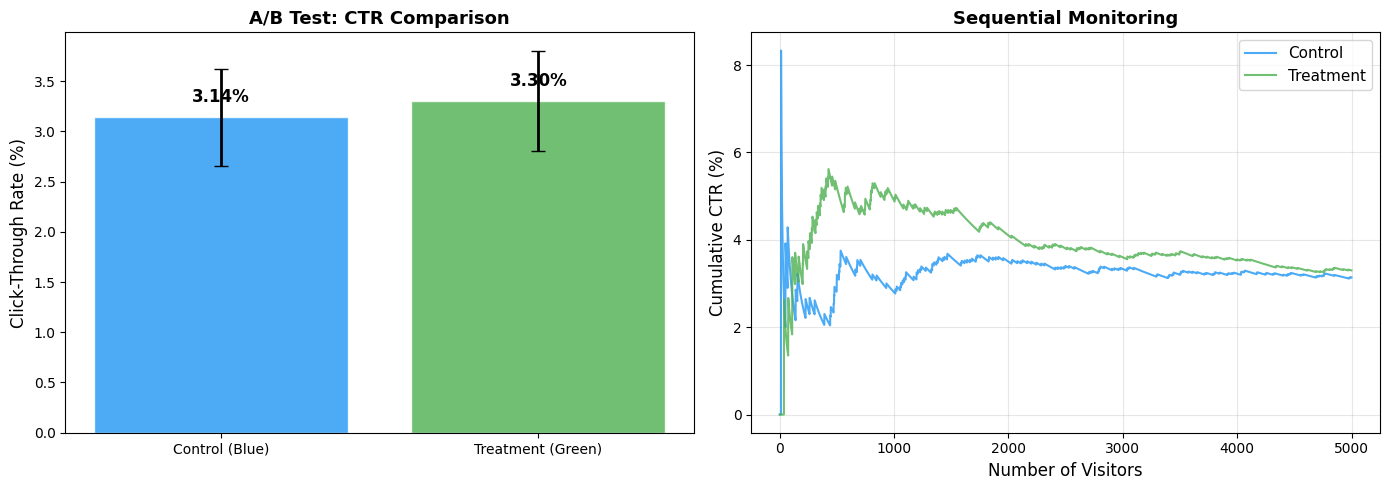

In [8]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

np.random.seed(42)

# Simulate A/B test data
n_A = 5000   # Visitors seeing blue button
n_B = 5000   # Visitors seeing green button

# True CTR: 3.2% for A, 3.8% for B (0.6% absolute lift)
clicks_A = np.random.binomial(1, 0.032, n_A)
clicks_B = np.random.binomial(1, 0.038, n_B)

ctr_A = clicks_A.mean()
ctr_B = clicks_B.mean()
lift = (ctr_B - ctr_A) / ctr_A * 100

print("=" * 60)
print("A/B TEST RESULTS")
print("=" * 60)
print(f"Control (Blue):  {ctr_A:.4f} CTR ({clicks_A.sum()} clicks / {n_A} visitors)")
print(f"Treatment (Green): {ctr_B:.4f} CTR ({clicks_B.sum()} clicks / {n_B} visitors)")
print(f"Absolute lift: {(ctr_B - ctr_A)*100:.2f} percentage points")
print(f"Relative lift: {lift:.1f}%")

# Two-proportion z-test
p_pool = (clicks_A.sum() + clicks_B.sum()) / (n_A + n_B)
se = np.sqrt(p_pool * (1 - p_pool) * (1/n_A + 1/n_B))
z_stat = (ctr_B - ctr_A) / se
p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))

print(f"\nz-statistic: {z_stat:.4f}")
print(f"p-value: {p_value:.6f}")
print(f"Significant at α=0.05? {'YES ✅' if p_value < 0.05 else 'NO ❌'}")

# Confidence interval for the difference
se_diff = np.sqrt(ctr_A*(1-ctr_A)/n_A + ctr_B*(1-ctr_B)/n_B)
ci = ((ctr_B - ctr_A) - 1.96*se_diff, (ctr_B - ctr_A) + 1.96*se_diff)
print(f"95% CI for difference: [{ci[0]*100:.2f}%, {ci[1]*100:.2f}%]")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# CTR comparison
bars = axes[0].bar(['Control (Blue)', 'Treatment (Green)'], [ctr_A*100, ctr_B*100],
                    color=['#2196F3', '#4CAF50'], edgecolor='white', alpha=0.8)
axes[0].errorbar([0, 1], [ctr_A*100, ctr_B*100],
                  yerr=[1.96*np.sqrt(ctr_A*(1-ctr_A)/n_A)*100, 1.96*np.sqrt(ctr_B*(1-ctr_B)/n_B)*100],
                  fmt='none', color='black', capsize=5, linewidth=2)
for bar, val in zip(bars, [ctr_A*100, ctr_B*100]):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.15,
                 f'{val:.2f}%', ha='center', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Click-Through Rate (%)', fontsize=12)
axes[0].set_title('A/B Test: CTR Comparison', fontweight='bold', fontsize=13)

# Sequential monitoring (showing cumulative results over time)
cum_ctr_A = np.cumsum(clicks_A) / np.arange(1, n_A + 1) * 100
cum_ctr_B = np.cumsum(clicks_B) / np.arange(1, n_B + 1) * 100
axes[1].plot(cum_ctr_A, color='#2196F3', linewidth=1.5, label='Control', alpha=0.8)
axes[1].plot(cum_ctr_B, color='#4CAF50', linewidth=1.5, label='Treatment', alpha=0.8)
axes[1].set_xlabel('Number of Visitors', fontsize=12)
axes[1].set_ylabel('Cumulative CTR (%)', fontsize=12)
axes[1].set_title('Sequential Monitoring', fontweight='bold', fontsize=13)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ab_test.png', dpi=150)
plt.show()